# Normalized versus unnormalized unlabeled loss

Compare finite self-training GD with unlabeled weights $S_\kappa(r)/\omega$ (default) and $S_\kappa(r)$. Both runs use Notebook 13's baseline parameters, identical training data and initialization, and raw confidence thresholds (`normalized_threshold=False`). Only `normalize_unlabeled_loss` changes; $\omega$ is computed in both runs.

Population error is evaluated analytically under the Gaussian mixture, conditional on the fitted classifier. This is one paired realization, not an average over seeds. Implementation: [`pseudo_residual`](../src/primitives.py) and the shared [`run_temporal_experiment`](temporal_error_attribution.py).

In [5]:
from dataclasses import replace
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit
from notebooks.temporal_error_attribution import TemporalExperimentParameters, run_temporal_experiment, plot_temporal_experiment
from notebooks.experiment_helpers import finite_state_observables, finite_update_observables
from scripts.plotting import plot_experiment

%matplotlib inline
from dataclasses import replace
from pathlib import Path
import sys
import numpy as np
import torch
from scipy.special import logit, ndtr
from matplotlib import pyplot as plt
from IPython.display import display, Markdown

In [2]:
PARAMETERS = TemporalExperimentParameters(
    seed=49,
    T=200,
    d=3_000,
    delta=8.0,
    rho=0.01,
    label_prior=0.2,
    sigma=1.0,
    signal_std=1.0,
    eta=0.5,
    penalty=0.1,
    pi=2.0,
    kappa=logit(0.8),
    include_bias=True,
    normalized_threshold=False,
)


In [3]:
runs = {
    label: run_temporal_experiment(replace(PARAMETERS, normalize_unlabeled_loss=normalize))
    for label, normalize in [("Normalized", True), ("Unnormalized", False)]
}

normalized, unnormalized = runs.values()
assert normalized.algo_cfg.normalize_unlabeled_loss
assert not unnormalized.algo_cfg.normalize_unlabeled_loss
assert torch.equal(normalized.X, unnormalized.X)
assert torch.equal(normalized.environment.Y, unnormalized.environment.Y)
assert torch.equal(normalized.environment.Delta, unnormalized.environment.Delta)
for field in ("w_init", "Y_init"):
    assert torch.equal(getattr(normalized.finite.initialization_, field),
                       getattr(unnormalized.finite.initialization_, field))

for label, run in runs.items():
    error = np.asarray(run.callback.history_["population_error"])
    print(f"{label:12s}  minimum error = {error.min():.6f} at t = {error.argmin():3d}"
          f"  final error = {error[-1]:.6f}")

Normalized    minimum error = 0.169634 at t =  45  final error = 0.200000
Unnormalized  minimum error = 0.170876 at t =  51  final error = 0.200000


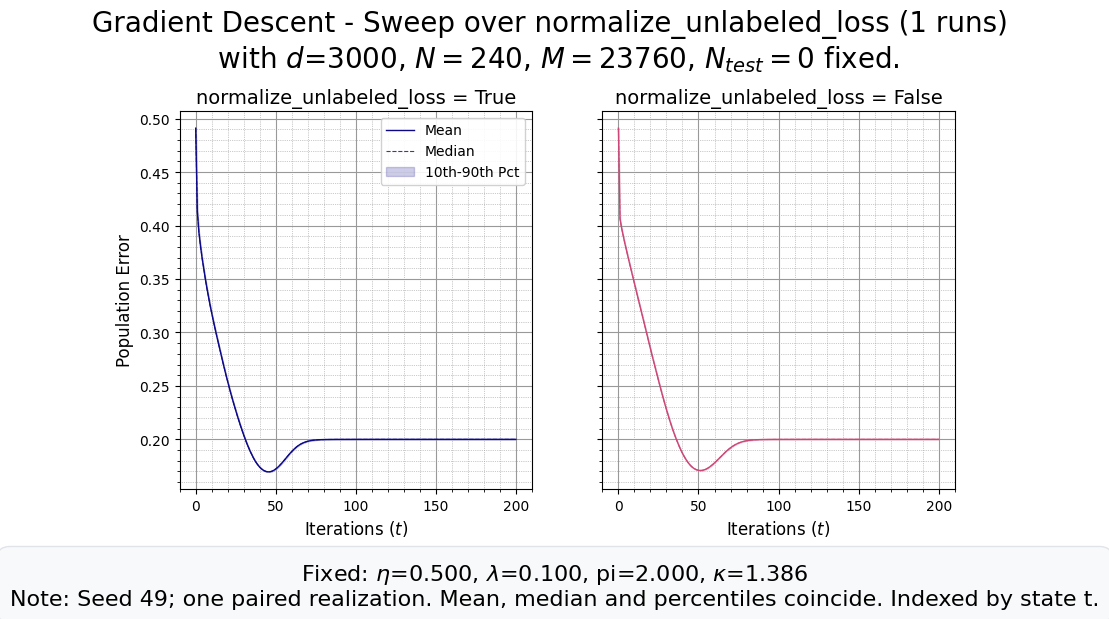

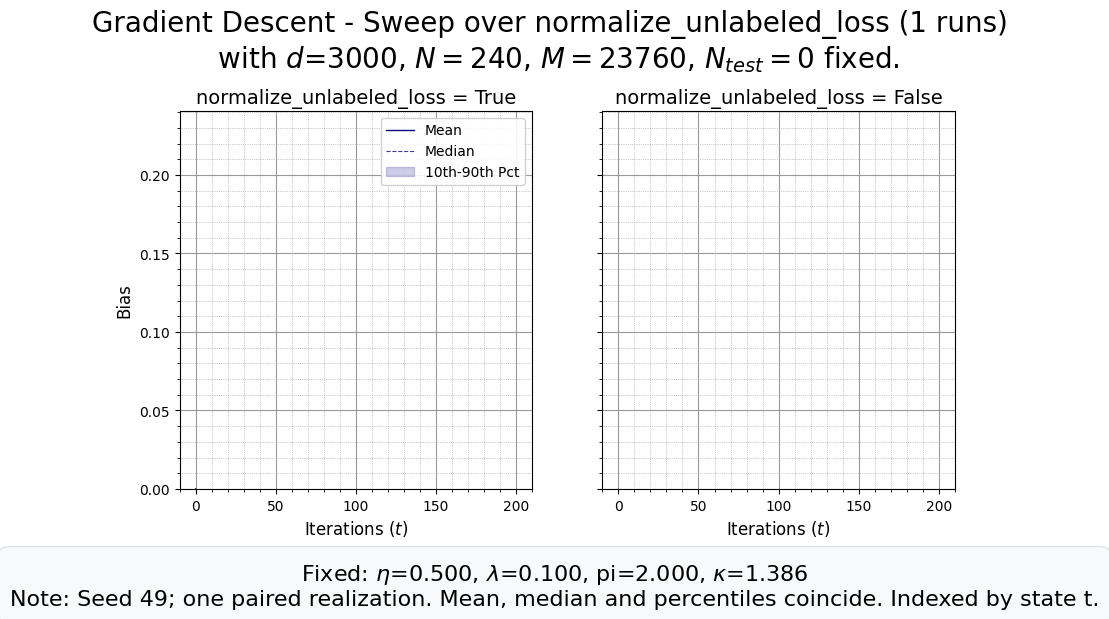

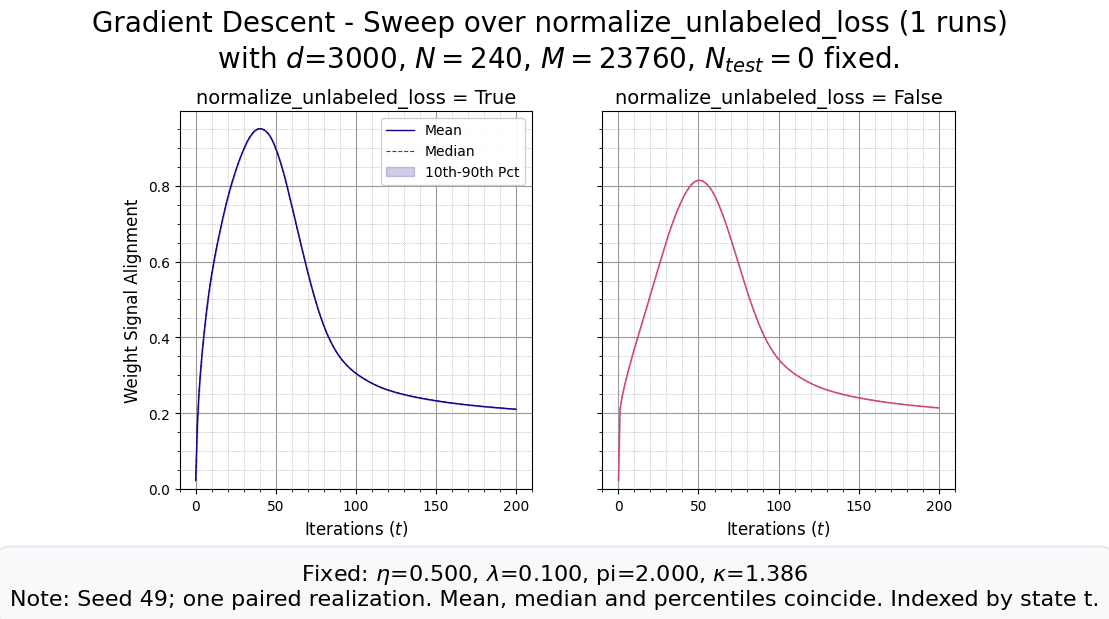

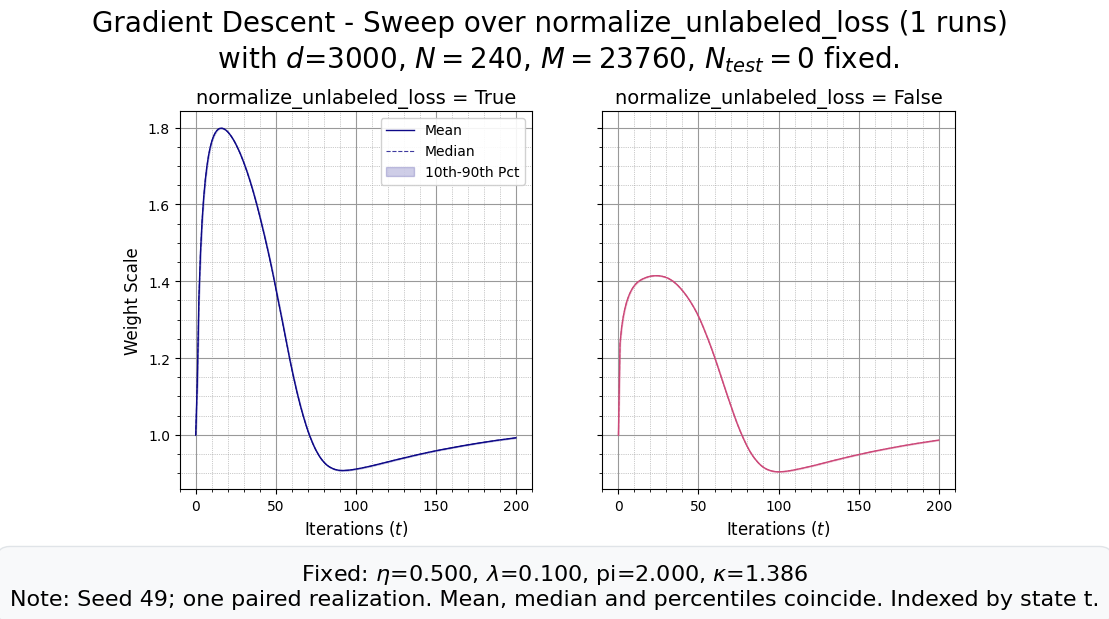

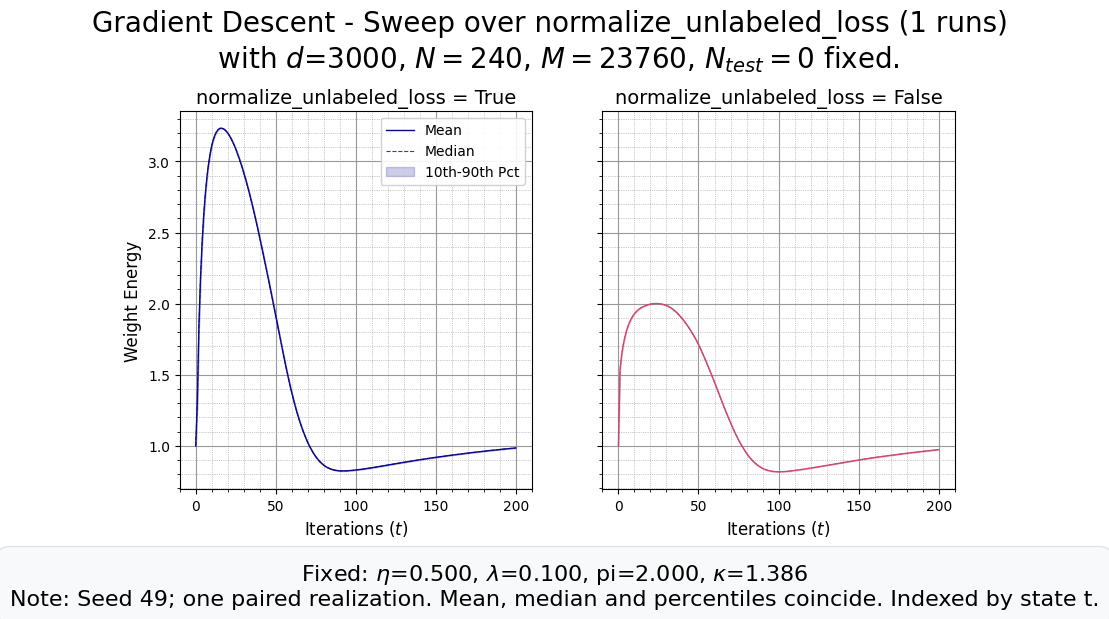

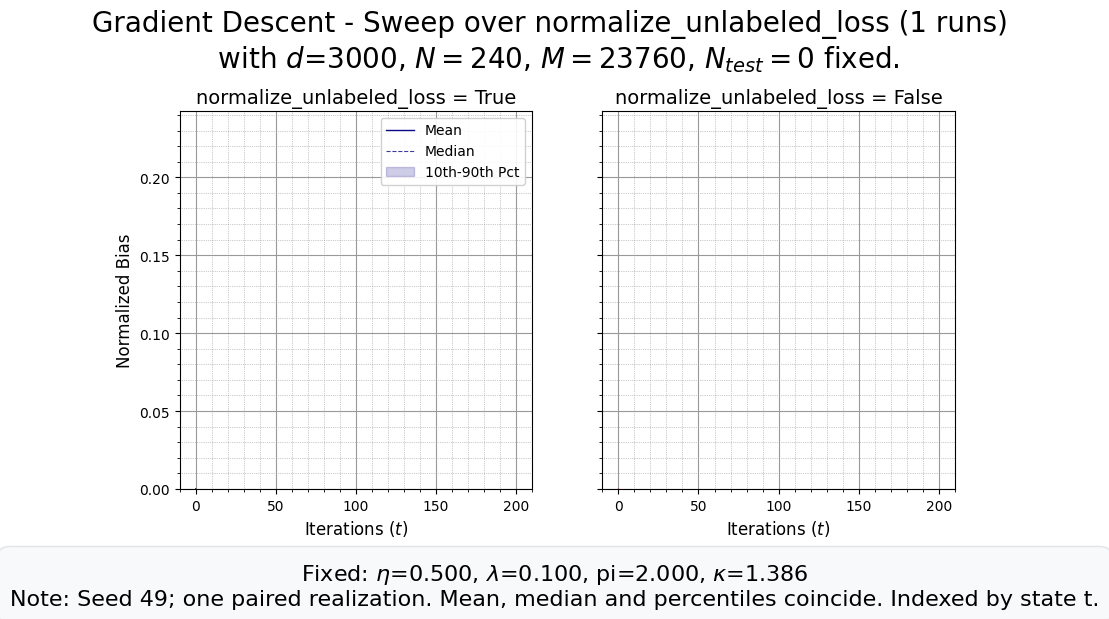

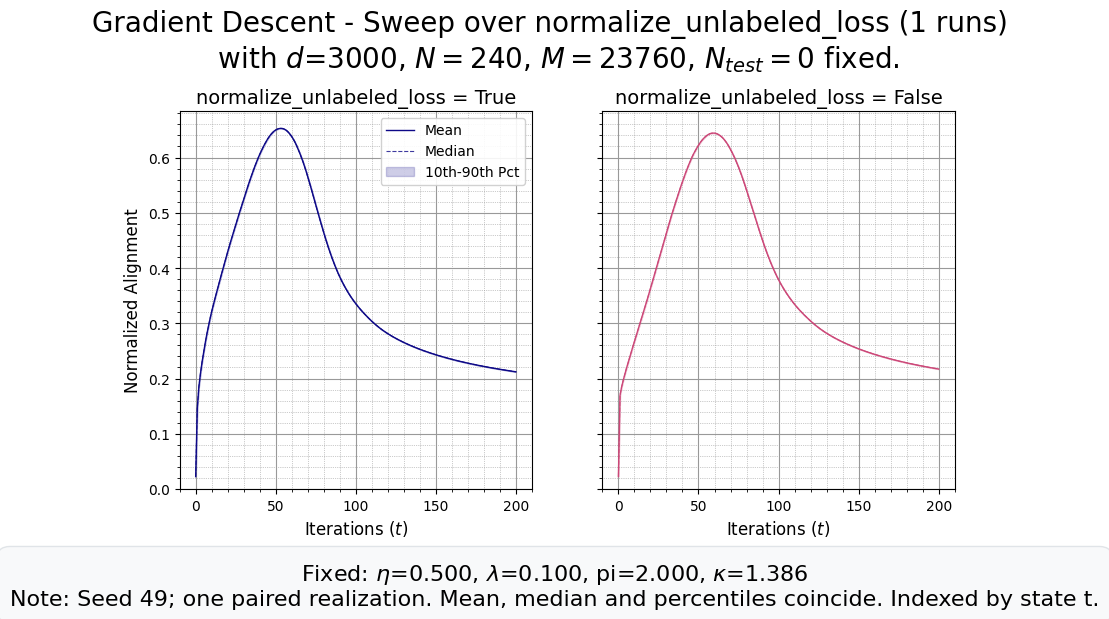

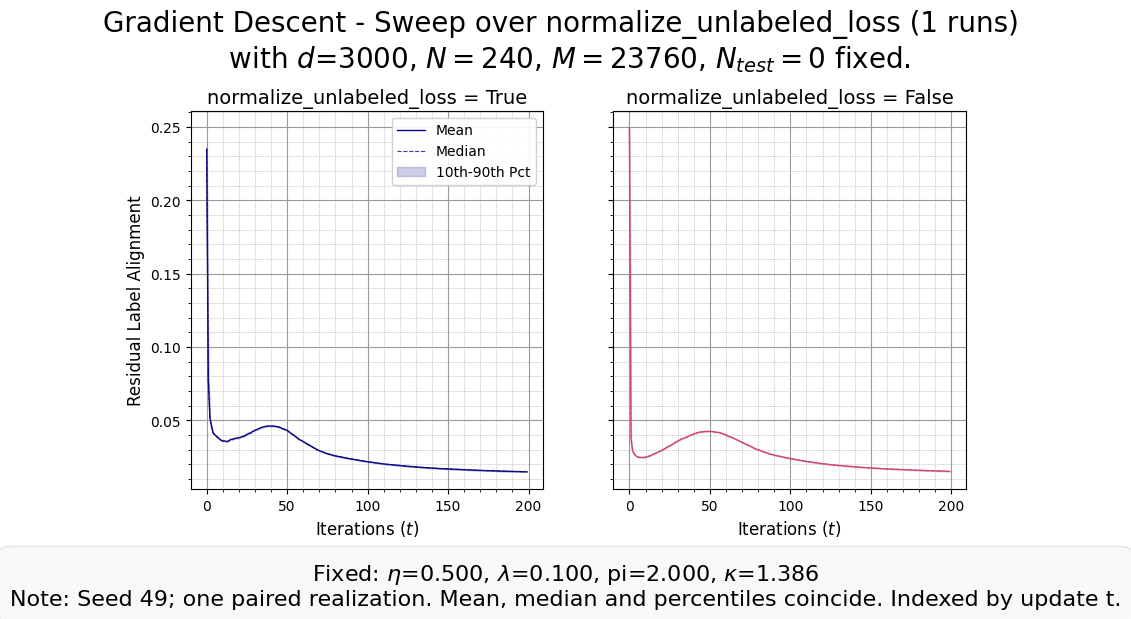

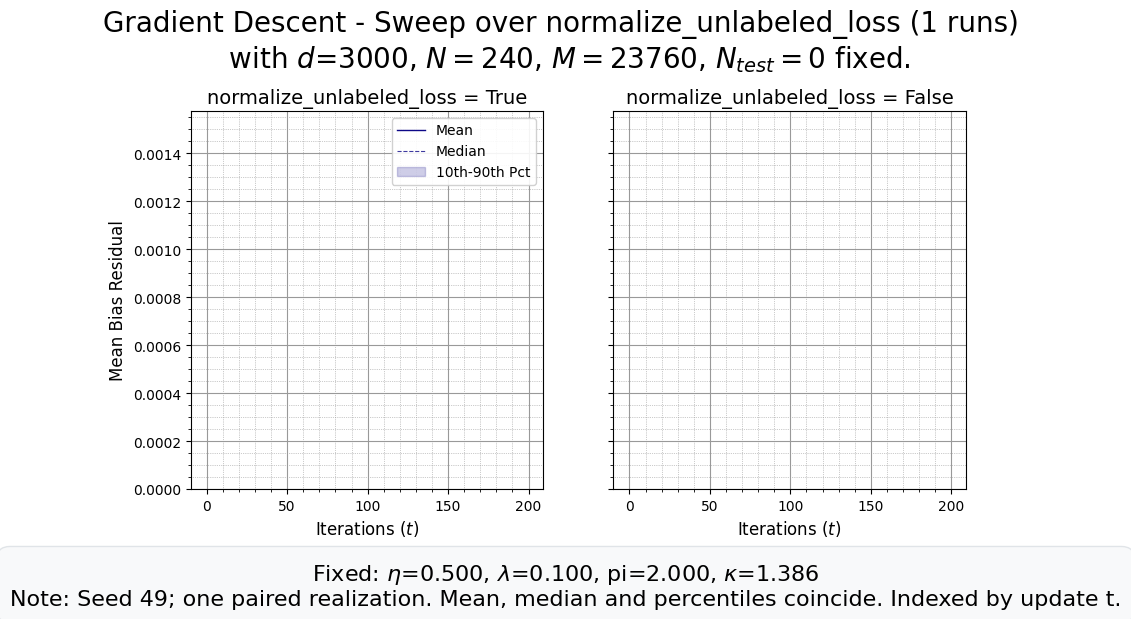

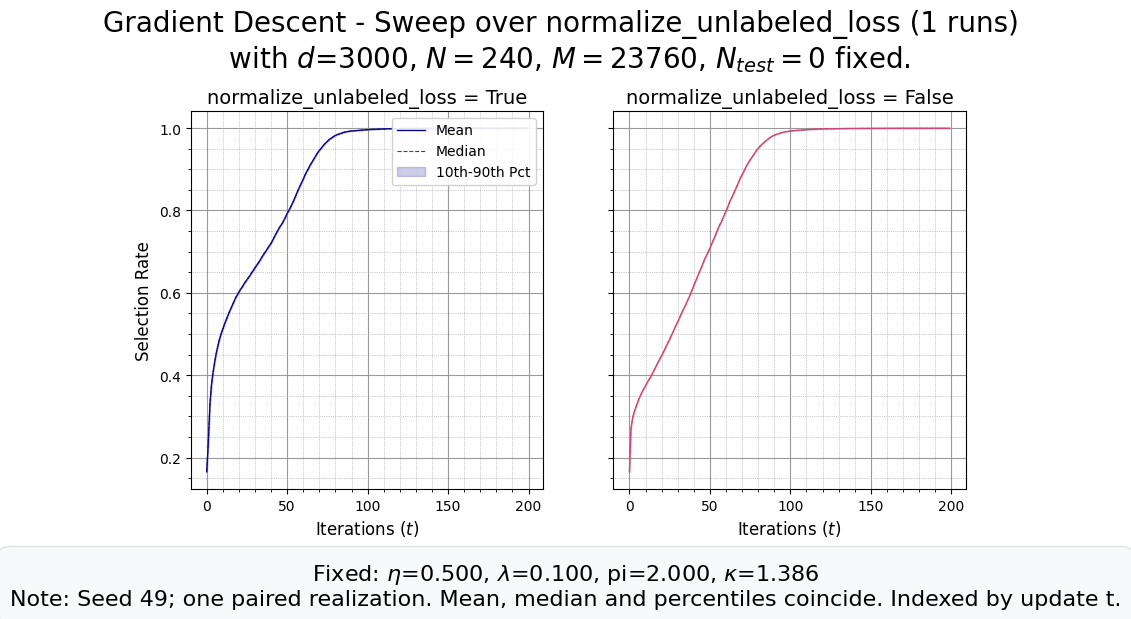

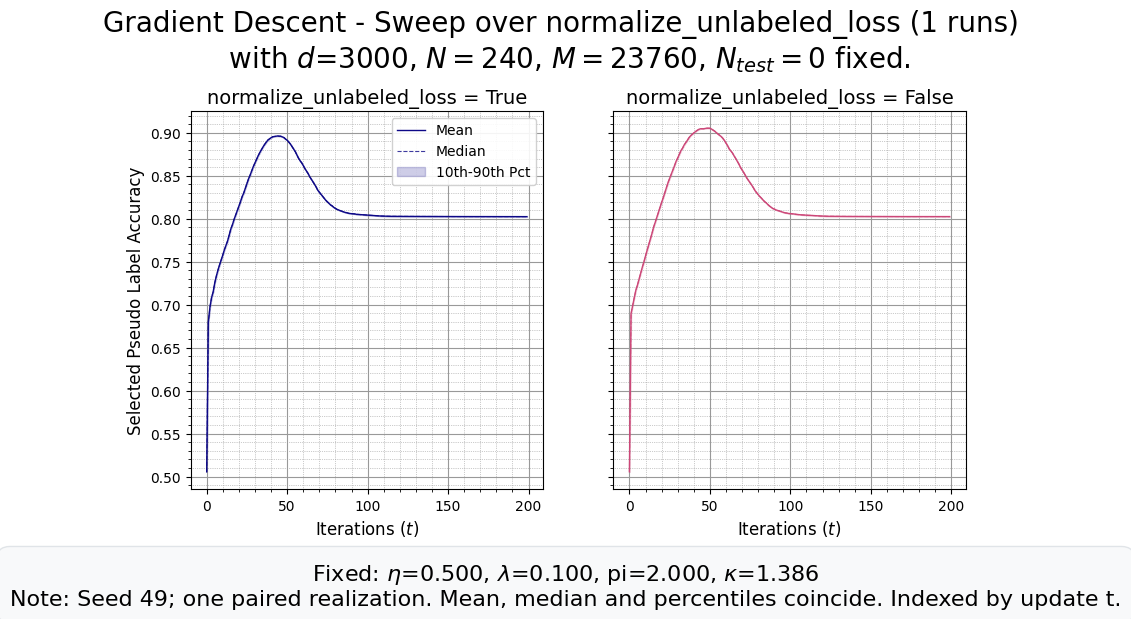

In [8]:
trajectories = {}
for label, run in runs.items():
    state = finite_state_observables(run)
    update = finite_update_observables(run)
    trajectories[label] = {
        "population_error": state["error"],
        "bias": state["bias"],
        "weight_signal_alignment": state["m"],
        "weight_scale": state["tau"],
        "weight_energy": state["energy"],
        "normalized_bias": run.error_diagnostics["finite"]["normalized_bias"],
        "normalized_alignment": run.error_diagnostics["finite"]["normalized_alignment"],
        "residual_label_alignment": update["chi"],
        "mean_bias_residual": update["zeta"],
        "selection_rate": update["omega"],
        "selected_pseudo_label_accuracy": update["accuracy"],
    }

# Shape expected by plot_experiment: (configurations, repetitions, times).
# State quantities have T+1 entries; update quantities have T entries.
for metric in trajectories["Normalized"]:
    values = np.stack([trajectory[metric] for trajectory in trajectories.values()])[:, None, :]
    plot_experiment(
        res=values,
        base_params={"eta": PARAMETERS.eta, "lambd": PARAMETERS.penalty,
                     "pi": PARAMETERS.pi, "kappa": PARAMETERS.kappa},
        d=PARAMETERS.d, N=normalized.environment.N, M=normalized.environment.M,
        N_test=0, T=values.shape[-1] - 1,
        algorithm_name="Gradient Descent",
        sweep_param_name="normalize_unlabeled_loss",
        sweep_param_values=[True, False],
        metric_name=metric,
        #allow_negative=True,
        extra_text=f"Seed {PARAMETERS.seed}; one paired realization. Mean, median and percentiles coincide. "
                   + ("Indexed by update t." if values.shape[-1] == PARAMETERS.T else "Indexed by state t."),
    )

In [ ]:
PARAMETERS = TemporalExperimentParameters(
    seed=49,
    T=200,
    d=3_000,
    delta=8.0,
    rho=0.01,
    label_prior=0.2,
    sigma=1.0,
    signal_std=1.0,
    eta=0.5,
    penalty=0.1,
    pi=2.0,
    kappa=logit(0.8),
    include_bias=True,
    normalized_threshold=False,
)


run = run_temporal_experiment(PARAMETERS)

In [ ]:
baseline_norm = plot_temporal_experiment(run, attribution_ylim=None, print_summary=False, show=False)
polish_attribution(baseline_norm, baseline_norm_run)
plt.close('all')
display(baseline_norm.figures['attribution'])
display(baseline_norm.figures['selection'])